In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import scipy

from flax import nnx
from torch.utils.data import DataLoader
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.dataset import get_iter
from src.datasets.sum import Addition
from src.decoding import make_autoregressive
from src.utils import parse_dict
from src.verifier import make_compute_returns

## Helpers

In [3]:
class StepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: chex.PRNGKey
    observations: chex.Array
    actions: chex.Array
    answers: chex.Array
    pointer_correct: chex.Array
    last_prompt_idx: int
    eos: chex.Array
    logits: chex.Array
    step_i: int = 0
    deterministic: int = 0
    """
    XXX: Set both to zero if we're using CoT tokens or predicting <EOS>

    XXX: Assume that all possible responses contain tokens with ID up to max_token_id_to_shift
         - You will have to include max_token_id_to_shift + 1 CoT tokens to get the code to run
    """
    correct_aware_shift: int = 0
    max_token_id_to_shift: int = 0


def predict_step(
    step_state: StepState,
):
    step_i = step_state.step_i
    rng, rng_step = jax.random.split(step_state.rng, 2)

    # Autoregressively decode
    module = nnx.merge(step_state.graphdef, step_state.rest, step_state.cache)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)
    logits = module({"sequence": step_state.observations[:, [step_i]],},)
    cache = nnx.state(module, nnx.Cache)

    logits = logits[:, 0]

    # Actual action taken, but output_tokens can be different
    action = jax.lax.cond(
        step_state.deterministic,
        lambda rng_step, logits: jnp.argmax(logits, axis=-1),
        jax.random.categorical,
        rng_step,
        logits,
    )

    is_prompt = step_i < step_state.last_prompt_idx
    pointer_correct = step_state.pointer_correct

    # Shift token by some amount if we know the steps are wrong
    curr_answers = step_state.answers[
        jnp.arange(len(pointer_correct)), pointer_correct
    ]

    reset_pointer = jnp.where(
        step_state.answers[:, 0] == action,
        1,
        0,
    )
    not_prompt_pointer = jax.lax.select(
        curr_answers == action,
        pointer_correct + 1,
        reset_pointer,
    )
    pointer_correct = jax.lax.select(
        is_prompt > 0.0,
        pointer_correct,
        not_prompt_pointer,
    )

    output_tokens = jnp.where(
        jnp.logical_and(
            curr_answers != action,
            action <= step_state.max_token_id_to_shift,
        ),
        action + step_state.correct_aware_shift,
        action,
    )

    # jax.debug.print(
    #     "step {w} is_prompt {v}: pointer {x} answer {y} pred {u} transition {z}",
    #     w=step_i,
    #     v=is_prompt,
    #     x=pointer_correct,
    #     y=curr_answers,
    #     u=action,
    #     z=output_tokens,
    # )

    # Check for prompt boundary
    output_tokens = jnp.where(
        is_prompt,
        step_state.observations[:, step_i + 1],
        output_tokens,
    )

    # Check if the first EOS has been generated
    eos = jnp.logical_or(
        output_tokens == step_state.eos_token,
        step_state.eos[:, step_i],
    )

    # Update the entries on the i'th step
    observations = step_state.observations.at[:, step_i + 1].set(output_tokens)
    actions = step_state.actions.at[:, step_i + 1].set(action)
    eos = step_state.eos.at[:, step_i + 1].set(eos)
    all_logits = step_state.logits.at[:, step_i + 1].set(logits)

    step_state = StepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        observations=observations,
        actions=actions,
        answers=step_state.answers,
        pointer_correct=pointer_correct,
        last_prompt_idx=step_state.last_prompt_idx,
        eos=eos,
        step_i=step_i + 1,
        deterministic=step_state.deterministic,
        correct_aware_shift=step_state.correct_aware_shift,
        max_token_id_to_shift=step_state.max_token_id_to_shift,
        logits=all_logits,
    )

    return step_state


@nnx.jit(static_argnames=["out_dim"])
def rollout(
    graphdef: Any,
    cache: Any,
    rest: Any,
    rng: chex.PRNGKey,
    batch: Any,
    out_dim: int,
    eos_token: int,
    deterministic: int = 0,
    correct_aware_shift: int = 0,
    max_token_id_to_shift: int = 0,
):
    questions = batch["sequence"]
    answers = batch["target"]
    pointer_correct = batch["pointer_correct"]
    question_mask = 1 - batch["mask"]
    last_prompt_idx = (
        jnp.sum(question_mask, axis=-1) + pointer_correct - 1
    ).astype(int)
    num_questions, max_step = questions.shape

    step_state = StepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        eos_token=eos_token,
        rng=rng,
        observations=questions,
        actions=jnp.zeros_like(questions, dtype=int),
        answers=answers,
        pointer_correct=pointer_correct,
        last_prompt_idx=last_prompt_idx,
        eos=jnp.zeros((num_questions, max_step)),
        deterministic=deterministic,
        correct_aware_shift=correct_aware_shift,
        max_token_id_to_shift=max_token_id_to_shift,
        logits=jnp.zeros((num_questions, max_step, out_dim)),
    )

    step_state = jax.lax.while_loop(
        lambda state: state.step_i < max_step - 1,
        predict_step,
        step_state,
    )

    return {
        "observations": step_state.observations,
        "actions": step_state.actions,
        "eos": step_state.eos,
        "question_mask": question_mask,
        "last_prompt_idx": last_prompt_idx,
        "logits": step_state.logits,
    }


In [4]:
Dtype = Any
Shape = tuple[int, ...]

@runtime_checkable
class HasCache(Protocol):
    def init_cache(self, input_shape: Shape, dtype: Dtype = jnp.float32): ...

def evaluate(
    learner_path,
    batch,
    out_dim,
    batch_size,
    eval_seed,
    num_evals,
    max_decode_len,
    dtype,
    eos_token_id,
    checkpoint_i=-1,
    stochastic=False,
    correct_aware_shift: int = 0,
    max_token_id_to_shift: int = 0,
):
    config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

    # Load model
    last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
    train_state = dill.load(
        open(os.path.join(learner_path, "models", last_step), "rb")
    )

    # print(train_state.params)
    model = nnx.merge(
        train_state.graphdef,
        train_state.params,
        train_state.rest,
    )

    rng = jax.random.PRNGKey(eval_seed)
    rng, rollout_rng = jax.random.split(rng)

    # Sample next batch and evaluate
    _, init_cache = make_autoregressive(
        model,
        max_decode_len=max_decode_len,
        batch_size=batch_size * num_evals,
        embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
        dtype=dtype,
        eval_mode=True,
    )
    cache = init_cache()
    graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

    rollout_res = rollout(
        graphdef,
        cache,
        rest,
        rollout_rng,
        batch,
        out_dim=out_dim,
        eos_token=eos_token_id,
        deterministic=1 - int(stochastic),
        correct_aware_shift=correct_aware_shift,
        max_token_id_to_shift=max_token_id_to_shift,
    )

    return rollout_res

## Evaluate

In [5]:
base_path = "/home/bryanpu1/projects/iclr_2026/icl_architecture/scaling_jax/results"

algo_name = "addition-max_int_64-no_eos-correctness_aware"
# run_name = "ppo-scratch_1M-no_cot_tokens-8x8-10-22-25_07_46_47-89a2c565-e62c-48da-a13c-b345bb018474"
run_name = "ppo-scratch_1M-no_correctness_aware-no_cot_tokens-8x8-10-22-25_07_49_04-456e8ca1-b8b5-434a-bbb1-40412b326c36"

learner_path = os.path.join(base_path, algo_name, run_name)

In [6]:
eval_seed = 42
num_evals = 1
max_batch_size = 100
max_decode_len = 3200
save_filename = f"res-{run_name}-decode_len_{max_decode_len}-num_evals_{num_evals}.dill"

config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
train_max_int = config_dict["dataset_kwargs"]["max_int"]
config_dict["dataset_kwargs"]["max_int"] = 4096
config_dict["gamma"] = 0.99
config = parse_dict(config_dict)
dataset_kwargs = config.dataset_kwargs

num_checkpoints = len(os.listdir(os.path.join(learner_path, "models")))

if config.dataset_name == "curriculum":
    max_num_bits = int(np.ceil(np.log2(dataset_kwargs.datasets[-1]["dataset_kwargs"]["max_int"])))
    train_val_ratio = dataset_kwargs.datasets[-1]["dataset_kwargs"]["train_val_ratio"]
    predict_eos = dataset_kwargs.datasets[-1]["dataset_kwargs"]["predict_eos"]
    num_cot_tokens = dataset_kwargs.datasets[-1]["dataset_kwargs"]["num_cot_tokens"]
    right_to_left = dataset_kwargs.datasets[-1]["dataset_kwargs"]["right_to_left"]
    correctness_aware = dataset_kwargs.datasets[-1]["dataset_kwargs"]["correctness_aware"]
else:
    max_num_bits = int(np.ceil(np.log2(dataset_kwargs.max_int)))
    train_val_ratio = dataset_kwargs.train_val_ratio
    predict_eos = dataset_kwargs.predict_eos
    num_cot_tokens = dataset_kwargs.num_cot_tokens
    right_to_left = dataset_kwargs.right_to_left
    correctness_aware = dataset_kwargs.correctness_aware

dataset = Addition(
    context_len=max_decode_len,
    max_int=2,
    train=False,
    seed=eval_seed,
    sequence_type="question_only",
    train_val_ratio=train_val_ratio,
    right_to_left=right_to_left,
    num_repeats=None,
    shuffle=False,
    exact=True,
    predict_eos=predict_eos,
    num_cot_tokens=num_cot_tokens,
    p_curriculum=0.0,
    p_inject_noop=0.0,
    max_noops=0,
    noop_as_pad=False,
    reverse_curriculum=False,
    correctness_aware=correctness_aware,
)

if os.path.isfile(save_filename):
    print("Loaded from storage")
    all_res = dill.load(open(save_filename, "rb"))
else:
    all_res = dict(
        results=dict(),
        metrics=dict(),
    )

    print(f"Max decode len: {max_decode_len}")

    for num_bits in range(1, max_num_bits + 1):
        curr_int = 2 ** num_bits
        num_pairs = curr_int * curr_int
        num_val = num_pairs - int(np.floor(num_pairs * train_val_ratio))
        batch_size = min(num_val, max_batch_size)
        dataset = Addition(
            context_len=max_decode_len,
            max_int=curr_int,
            train=False,
            seed=eval_seed,
            sequence_type="question_only",
            train_val_ratio=train_val_ratio,
            right_to_left=right_to_left,
            num_repeats=None,
            shuffle=False,
            exact=True,
            predict_eos=predict_eos,
            num_cot_tokens=num_cot_tokens,
            p_curriculum=0.0,
            p_inject_noop=0.0,
            max_noops=0,
            noop_as_pad=False,
            reverse_curriculum=False,
            correctness_aware=correctness_aware,
        )

        compute_returns = make_compute_returns(config, dataset.eos_token_id)

        print(f"Max int: {curr_int}, batch size: {batch_size}")

        out_dim = int(dataset.output_space.n)
        data_loader = DataLoader(
            dataset,
            batch_size=batch_size,
            num_workers=0,
        )
        data_iter = get_iter(data_loader, None, dtype)
        batch = next(data_iter)
        batch = {
            "sequence": np.repeat(batch["sequence"], num_evals, axis=0),
            "mask": np.repeat(batch["mask"], num_evals, axis=0),
            "target": np.repeat(batch["target"], num_evals, axis=0),
            "pointer_correct": np.repeat(batch["pointer_correct"], num_evals, axis=0),
        }

        for checkpoint_i in range(num_checkpoints):
            all_res["results"].setdefault(checkpoint_i, dict())
            all_res["metrics"].setdefault(checkpoint_i, dict())

            all_res["results"][checkpoint_i][num_bits] = evaluate(
                learner_path=learner_path,
                batch=batch,
                out_dim=out_dim,
                batch_size=batch_size,
                eval_seed=eval_seed,
                num_evals=num_evals,
                max_decode_len=max_decode_len,
                dtype=dtype,
                eos_token_id=dataset.eos_token_id,
                checkpoint_i=checkpoint_i,
                stochastic=True,
                correct_aware_shift=dataset.correctness_aware_tokens_offset,
                max_token_id_to_shift=dataset.max_token_id_to_shift,
            )

            returns, successes, response_lengths = compute_returns(
                {
                    "sequence": batch["sequence"],
                    "target": batch["target"],
                    "observations": all_res["results"][checkpoint_i][num_bits]["observations"],
                    "actions": all_res["results"][checkpoint_i][num_bits]["actions"],
                },
                all_res["results"][checkpoint_i][num_bits]["last_prompt_idx"],
                is_eval=False,
            )

            all_res["metrics"][checkpoint_i][num_bits] = {
                "successes": successes.reshape((batch_size, num_evals)),
                "response_lengths": response_lengths.reshape((batch_size, num_evals)),
            }
    dill.dump(all_res, open(save_filename, "wb"))

Max decode len: 3200
Max int: 2, batch size: 1
Max int: 4, batch size: 2
Max int: 8, batch size: 7
Max int: 16, batch size: 26
Max int: 32, batch size: 100
Max int: 64, batch size: 100
Max int: 128, batch size: 100
Max int: 256, batch size: 100
Max int: 512, batch size: 100
Max int: 1024, batch size: 100
Max int: 2048, batch size: 100
Max int: 4096, batch size: 100


## Response Length and Success Rates

In [7]:
skip_step = 10
checkpoints = None

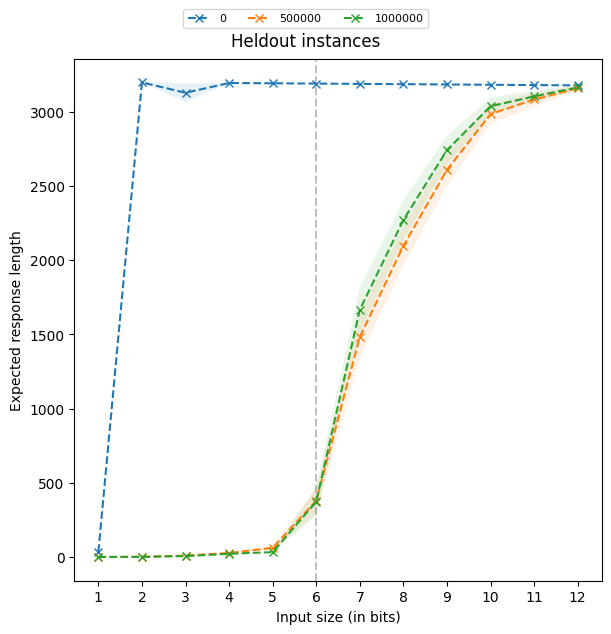

In [8]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    input_length_range = sorted(curr_metric.keys())
    expected_response_lengths = []
    for num_bits in input_length_range:
        expected_response_lengths.append((
            np.mean(curr_metric[num_bits]["response_lengths"]),
            np.std(curr_metric[num_bits]["response_lengths"]) / np.sqrt(
                curr_metric[num_bits]["response_lengths"].shape[0]
                * curr_metric[num_bits]["response_lengths"].shape[1]
            ),
        ))

    expected_response_lengths = np.array(expected_response_lengths)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)
    ax.plot(
        input_length_range,
        expected_response_lengths[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_response_lengths[:, 0] + expected_response_lengths[:, 1],
        expected_response_lengths[:, 0] - expected_response_lengths[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Expected response length")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

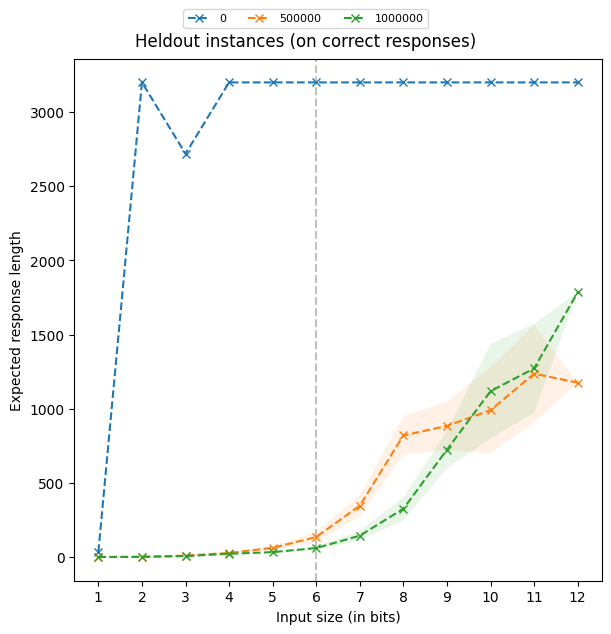

In [9]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    input_length_range = sorted(curr_metric.keys())
    expected_response_lengths = []
    for num_bits in input_length_range:
        success_runs = np.where(curr_metric[num_bits]["successes"])[0]
        if len(success_runs) == 0:
            expected_response_lengths.append((max_decode_len, 0.0))
        else:    
            expected_response_lengths.append((
                np.mean(curr_metric[num_bits]["response_lengths"][success_runs]),
                np.std(curr_metric[num_bits]["response_lengths"][success_runs]) / np.sqrt(
                    curr_metric[num_bits]["response_lengths"][success_runs].shape[0]
                    * curr_metric[num_bits]["response_lengths"][success_runs].shape[1]
                ),
            ))

    expected_response_lengths = np.array(expected_response_lengths)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)
    ax.plot(
        input_length_range,
        expected_response_lengths[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_response_lengths[:, 0] + expected_response_lengths[:, 1],
        expected_response_lengths[:, 0] - expected_response_lengths[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Expected response length")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances (on correct responses)")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

[1.         0.         0.14285714 0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]
[1.   1.   1.   1.   1.   0.92 0.6  0.46 0.25 0.09 0.05 0.01]
[1.   1.   1.   1.   1.   0.9  0.5  0.32 0.18 0.07 0.04 0.01]


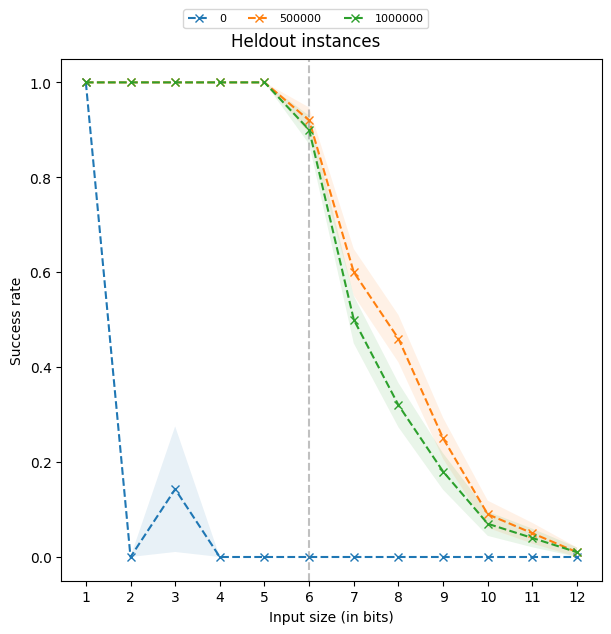

In [10]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    input_length_range = sorted(curr_metric.keys())
    expected_successes = []
    for num_bits in input_length_range:
        expected_successes.append((
            np.mean(curr_metric[num_bits]["successes"]),
            np.std(curr_metric[num_bits]["successes"]) / np.sqrt(
                curr_metric[num_bits]["successes"].shape[0]
                * curr_metric[num_bits]["successes"].shape[1]
            ),
        ))

    expected_successes = np.array(expected_successes)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)
    print(expected_successes[:, 0])
    ax.plot(
        input_length_range,
        expected_successes[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_successes[:, 0] + expected_successes[:, 1],
        expected_successes[:, 0] - expected_successes[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Success rate")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

## Entropy

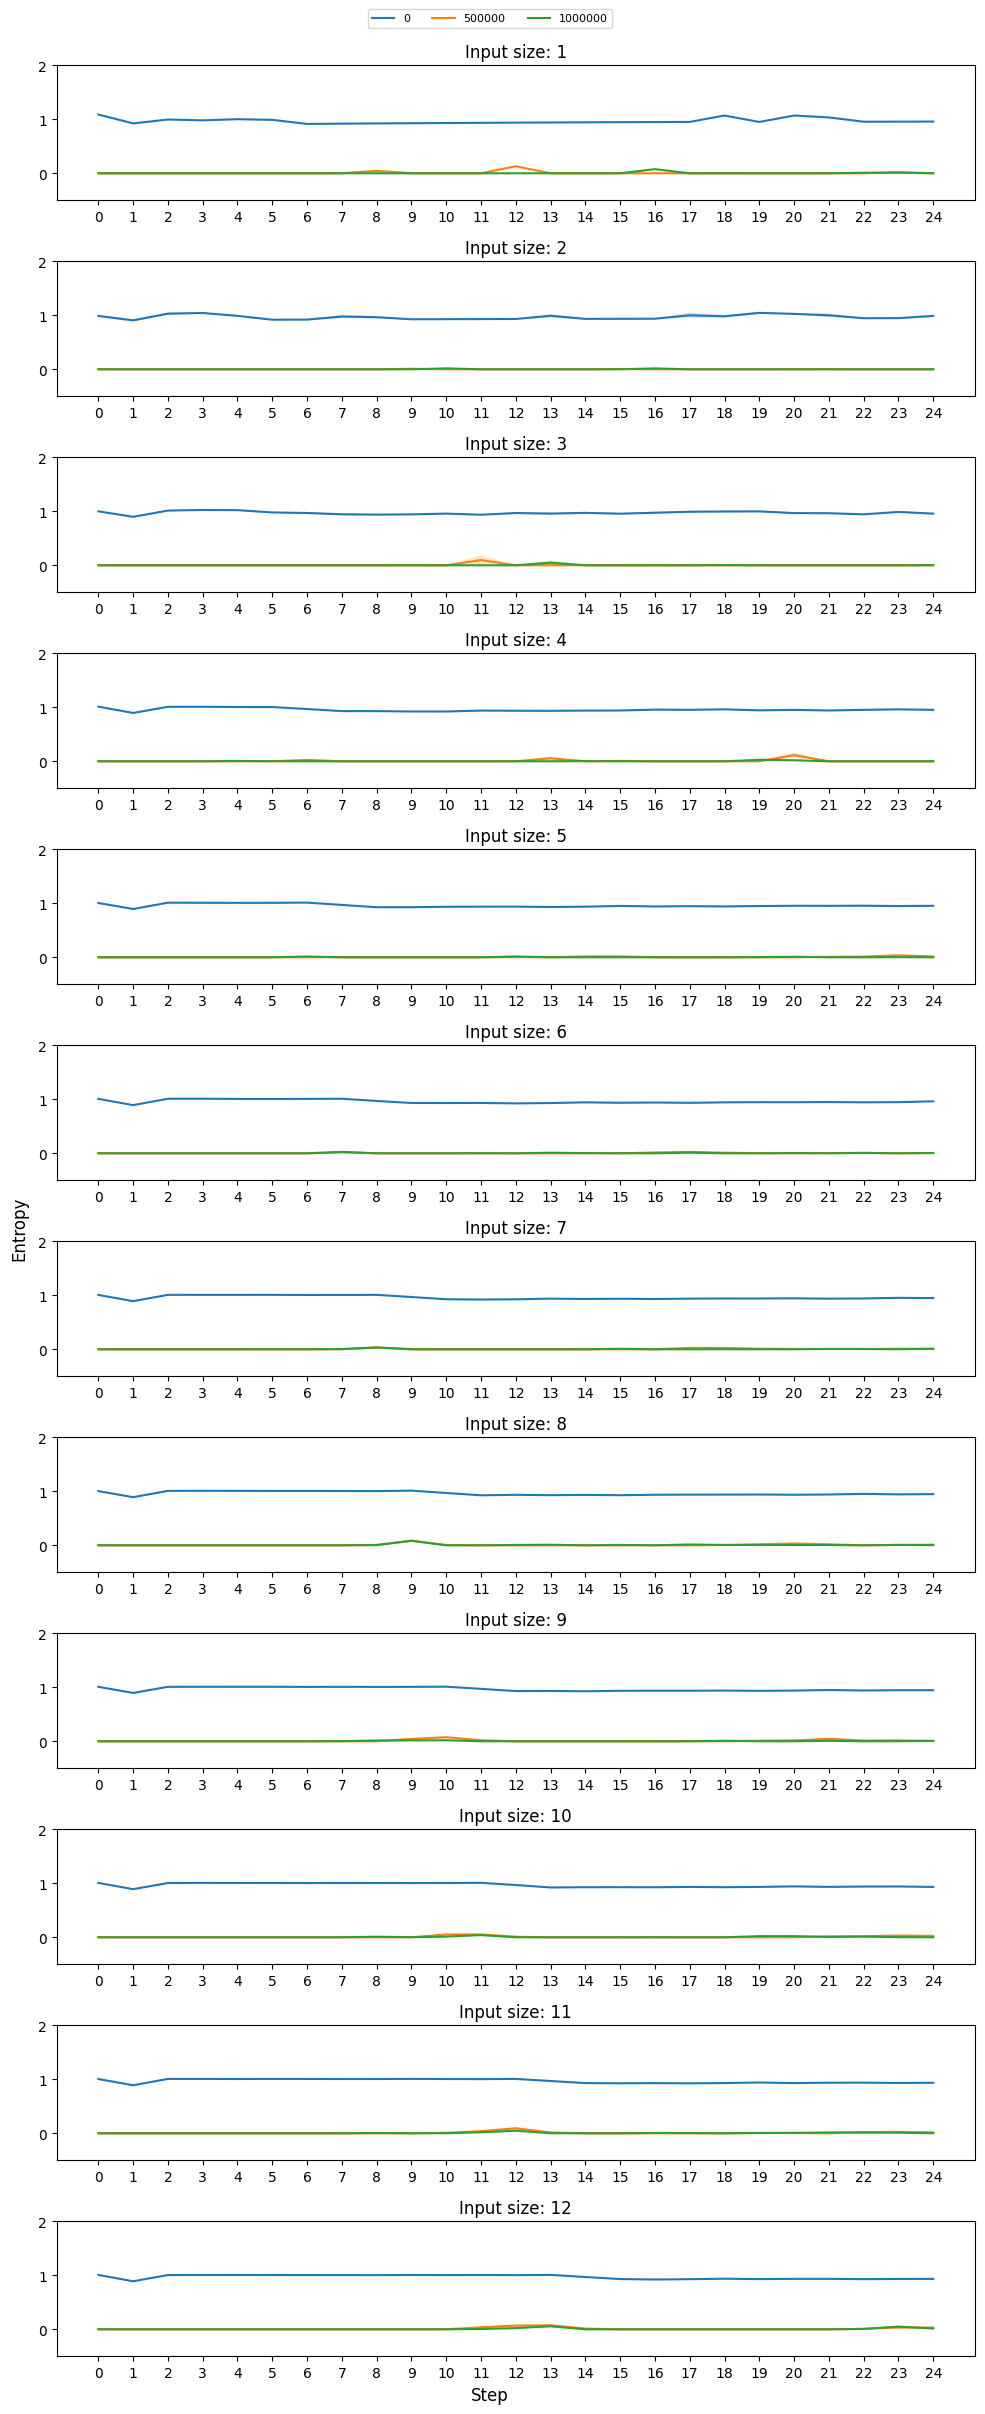

In [11]:
max_x = min(max_decode_len, 25)
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

fig, axs = plt.subplots(
    len(all_res["results"][0]),
    1,
    figsize=(
        10,
        2 * len(all_res["results"][0])
    ),
)
for checkpoint_i in all_res["results"]:
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    for plot_i, (input_size, curr_res) in enumerate(all_res["results"][checkpoint_i].items()):
        logits = curr_res["logits"][..., input_size:, :]
        logits = logits.reshape((-1, *logits.shape[1:]))
        entropies = optax.softmax_cross_entropy(logits, jax.nn.softmax(logits, axis=-1))
        mean_entropy = jnp.mean(entropies, axis=0)[:max_x]
        std_entropy = (jnp.std(entropies, axis=0) / np.sqrt(len(entropies)))[:max_x]

        x_range = np.arange(len(mean_entropy))
        axs[plot_i].plot(
            x_range,
            mean_entropy,
            label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 0 else "",
        )
        axs[plot_i].fill_between(
            x_range,
            mean_entropy - std_entropy,
            mean_entropy + std_entropy,
            alpha=0.2,
        )

        axs[plot_i].set_title(f"Input size: {input_size}")
        axs[plot_i].set_xticks(x_range)
        axs[plot_i].set_ylim(-0.5, 2.0)

fig.supylabel('Entropy')
fig.supxlabel('Step')
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)
plt.tight_layout()

## Check greedy actions

In [12]:
save_filename_match_results = f"res-{run_name}-decode_len_{max_decode_len}-num_evals_{num_evals}-match_results.dill"

if os.path.isfile(save_filename_match_results):
    print("Loaded from storage")
    match_results = dill.load(open(save_filename_match_results, "rb"))
else:
    match_results = dict()
    for checkpoint_i in all_res["results"].keys():
        match_results[checkpoint_i] = dict()
        for num_bits in range(1, max_num_bits + 1):
            match_results[checkpoint_i][num_bits] = dict()

    for num_bits in range(1, max_num_bits + 1):
        curr_int = 2 ** num_bits
        num_pairs = curr_int * curr_int
        num_val = num_pairs - int(np.floor(num_pairs * train_val_ratio))
        batch_size = min(num_val, max_batch_size)

        dataset = Addition(
            context_len=max_decode_len,
            max_int=curr_int,
            train=False,
            seed=eval_seed,
            sequence_type="question_only",
            train_val_ratio=train_val_ratio,
            right_to_left=right_to_left,
            num_repeats=None,
            shuffle=False,
            exact=True,
            predict_eos=predict_eos,
            num_cot_tokens=num_cot_tokens,
            p_curriculum=0.0,
            p_inject_noop=0.0,
            max_noops=0,
            noop_as_pad=False,
        )
        data_loader = DataLoader(
            dataset,
            batch_size=batch_size,
            num_workers=0,
        )
        data_iter = get_iter(data_loader, None, dtype)
        batch = next(data_iter)

        for bit_match_idx in range(max_num_bits):
            if bit_match_idx >= num_bits:
                continue


            for checkpoint_i in all_res["results"].keys():
                match_results[checkpoint_i][num_bits][bit_match_idx] = dict()

                logits = all_res["results"][checkpoint_i][num_bits]["logits"]
                first_bit_match = (
                    batch["target"][:, 1 + bit_match_idx]
                    == np.argmax(logits[::num_evals, num_bits * 2 + 2 + 1 + bit_match_idx], axis=-1)
                )

                print("==" * 50)
                print("Num bits: {}, bit {} match: {}% ({}/{})".format(
                    num_bits,
                    bit_match_idx + 1,
                    np.mean(first_bit_match),
                    np.sum(first_bit_match),
                    first_bit_match.size,
                ))

                match_results[checkpoint_i][num_bits][bit_match_idx]["bit_match"] = first_bit_match
                match_results[checkpoint_i][num_bits][bit_match_idx]["entropies"] = None

                not_matched_logits = logits[::num_evals, num_bits * 2 + 2 + bit_match_idx][np.logical_not(first_bit_match)]
                if not_matched_logits.size > 0:
                    not_matched_logits = not_matched_logits.reshape(
                        (-1, *not_matched_logits.shape[1:])
                    )
                    unique_ints, counts = np.unique(
                        np.argmax(not_matched_logits, axis=-1),
                        return_counts=True,
                    )
                    entropies = optax.softmax_cross_entropy(
                        not_matched_logits,
                        jax.nn.softmax(not_matched_logits, axis=-1),
                    )
                    # print(
                    #     unique_ints, counts
                    # )
                    # print("Entropies for not matched: (med {:.5f}) (max {:.5f}) (min {:.5f})".format(
                    #     np.median(entropies),
                    #     np.max(entropies),
                    #     np.min(entropies),
                    # ))
                    match_results[checkpoint_i][num_bits][bit_match_idx]["entropies"] = entropies
    dill.dump(match_results, open(save_filename_match_results, "wb"))

Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 1, bit 1 match: 1.0% (1/1)
Num bits: 1, bit 1 match: 0.0% (0/1)
Num bits: 2, bit 1 match: 0.0% (0/2)
Num bits: 2, bit 1 match: 1.0% (2/2)
Num bits: 2, bit 1 match: 1.0% (2/2)
Num bits: 2, bit 1 match: 1.0% (2/2)
Num bits: 2, bit 1 match: 1.0% (2/2)
Num bits: 2, bit 1 match: 1.0% (2/2)
N

## Bit Match %

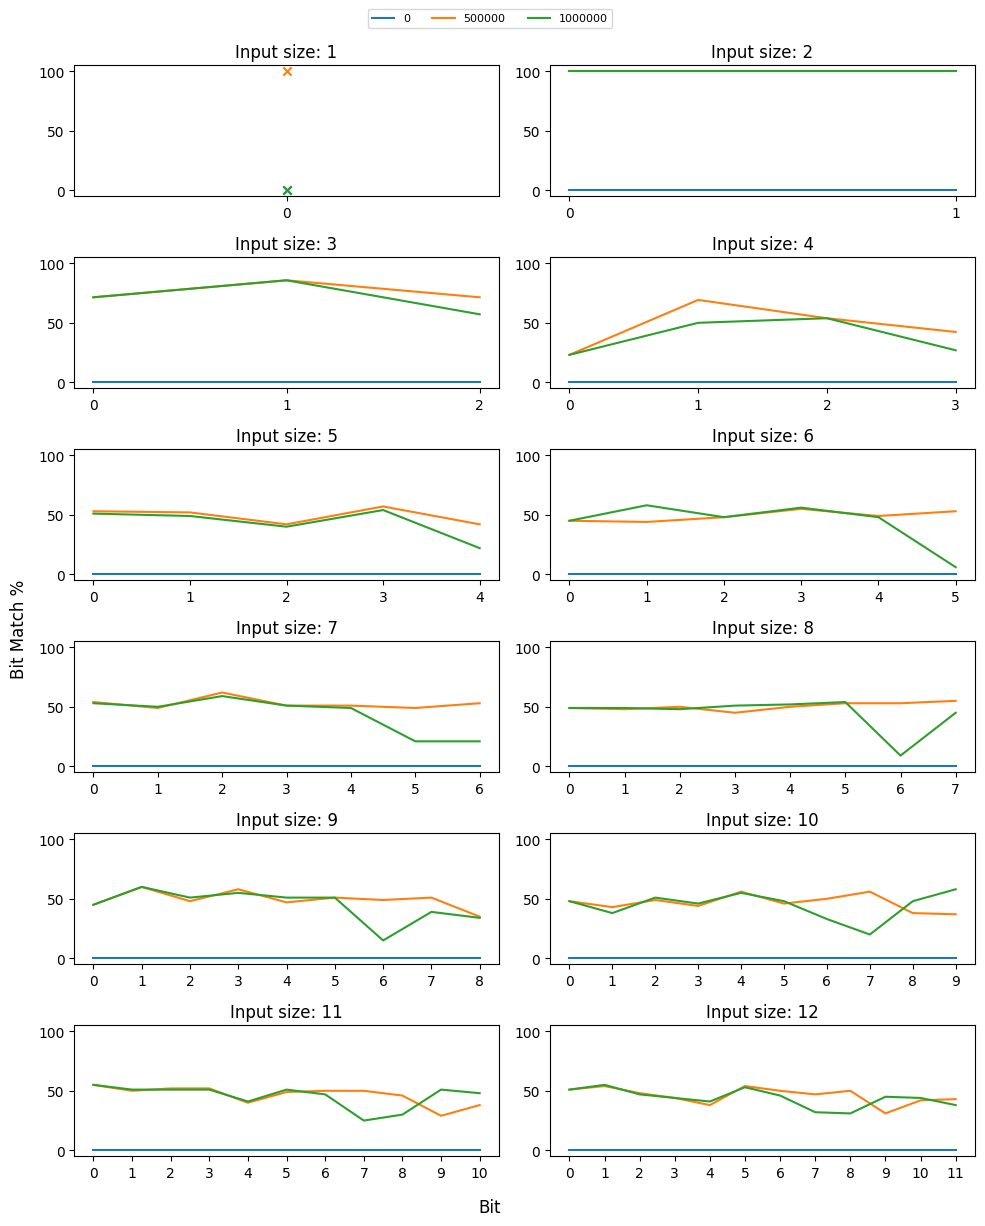

In [13]:
max_x = min(max_decode_len, 25)
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(match_results.keys()))

fig, axs = plt.subplots(
    int(np.ceil(len(match_results[0]) / 2)),
    2,
    figsize=(
        10,
        len(match_results[0])
    ),
)
axs = axs.flatten()
for checkpoint_i in match_results:
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    for plot_i, (input_size, curr_res) in enumerate(match_results[checkpoint_i].items()):
        x_range = sorted(list(curr_res.keys()))
        num_matches = [np.mean(curr_res[bit_match_idx]["bit_match"]) * 100 for bit_match_idx in x_range]
        
        if len(x_range) == 1:
            axs[plot_i].scatter(
                x_range,
                num_matches,
                marker="x"
            )
        else:
            axs[plot_i].plot(
                x_range,
                num_matches,
                label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 1 else "",
            )

        if checkpoint_i == 0:
            axs[plot_i].set_title(f"Input size: {input_size}")
            axs[plot_i].set_xticks(x_range)
            axs[plot_i].set_ylim(-5, 105)

fig.supylabel('Bit Match %')
fig.supxlabel('Bit')
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)
plt.tight_layout()

## Entropy on incorrect instances

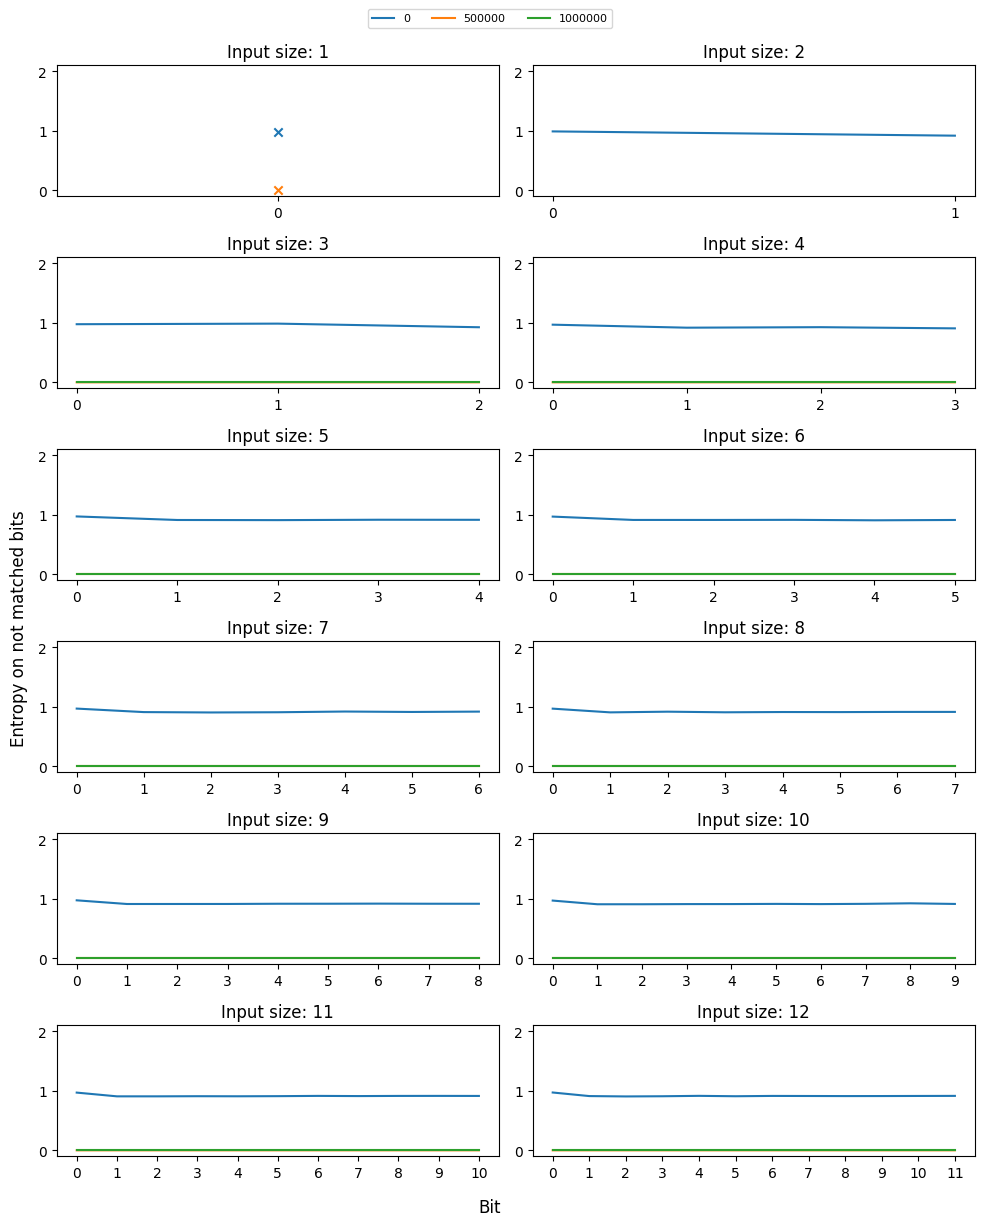

In [14]:
max_x = min(max_decode_len, 25)
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(match_results.keys()))

fig, axs = plt.subplots(
    int(np.ceil(len(match_results[0]) / 2)),
    2,
    figsize=(
        10,
        len(match_results[0])
    ),
)
axs = axs.flatten()
for checkpoint_i in match_results:
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    for plot_i, (input_size, curr_res) in enumerate(match_results[checkpoint_i].items()):
        x_range = list(filter(
            lambda bit_match_idx: curr_res[bit_match_idx]["entropies"] is not None,
            sorted(list(curr_res.keys())),
        ))
        entropies = [
            np.nanmedian(curr_res[bit_match_idx]["entropies"])
            for bit_match_idx in x_range
        ]
        
        if len(x_range) == 1:
            axs[plot_i].scatter(
                x_range,
                entropies,
                marker="x"
            )
        else:
            axs[plot_i].plot(
                x_range,
                entropies,
                label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 1 else "",
            )

        if checkpoint_i == 0:
            axs[plot_i].set_title(f"Input size: {input_size}")
            axs[plot_i].set_xticks(x_range)
            axs[plot_i].set_ylim(-0.1, 2.1)

fig.supylabel('Entropy on not matched bits')
fig.supxlabel('Bit')
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)
plt.tight_layout()

### Note
`supervised-nope-scratch-32-noop_p0.1_m5-stop_on_empty-10-13-25_03_46_02-7da06c7f-2f4a-4bda-a16c-834072183754`
- Heldout instances of in-distribution length has 100% success rate, when supervised trained with CoT
- When trained with 1M steps, the first bit matches on all compared out-of-distribution length instances (200 instances)
    - Error starts compounding after that
    - Earlier model fails on shorter length instances

## Entropy in sampled trajectories

In [15]:
all_res["results"].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [16]:
checkpoint_i = 15

In [17]:
curr_actions = all_res["results"][checkpoint_i][6]["actions"]
curr_actions = curr_actions.reshape((-1, 5, curr_actions.shape[-1]))

In [18]:
curr_obss = all_res["results"][checkpoint_i][6]["observations"]
curr_obss = curr_obss.reshape((-1, num_evals, curr_obss.shape[-1]))

In [19]:
all_matches = True
question_end_idx = np.where(curr_obss[0][0] == 3)[0][0]
for eval_i in range(num_evals):
    all_matches = all_matches and np.all(curr_obss[0][0, :question_end_idx] == curr_obss[0][eval_i, :question_end_idx])
    if not all_matches:
        break

print(all_matches)

True


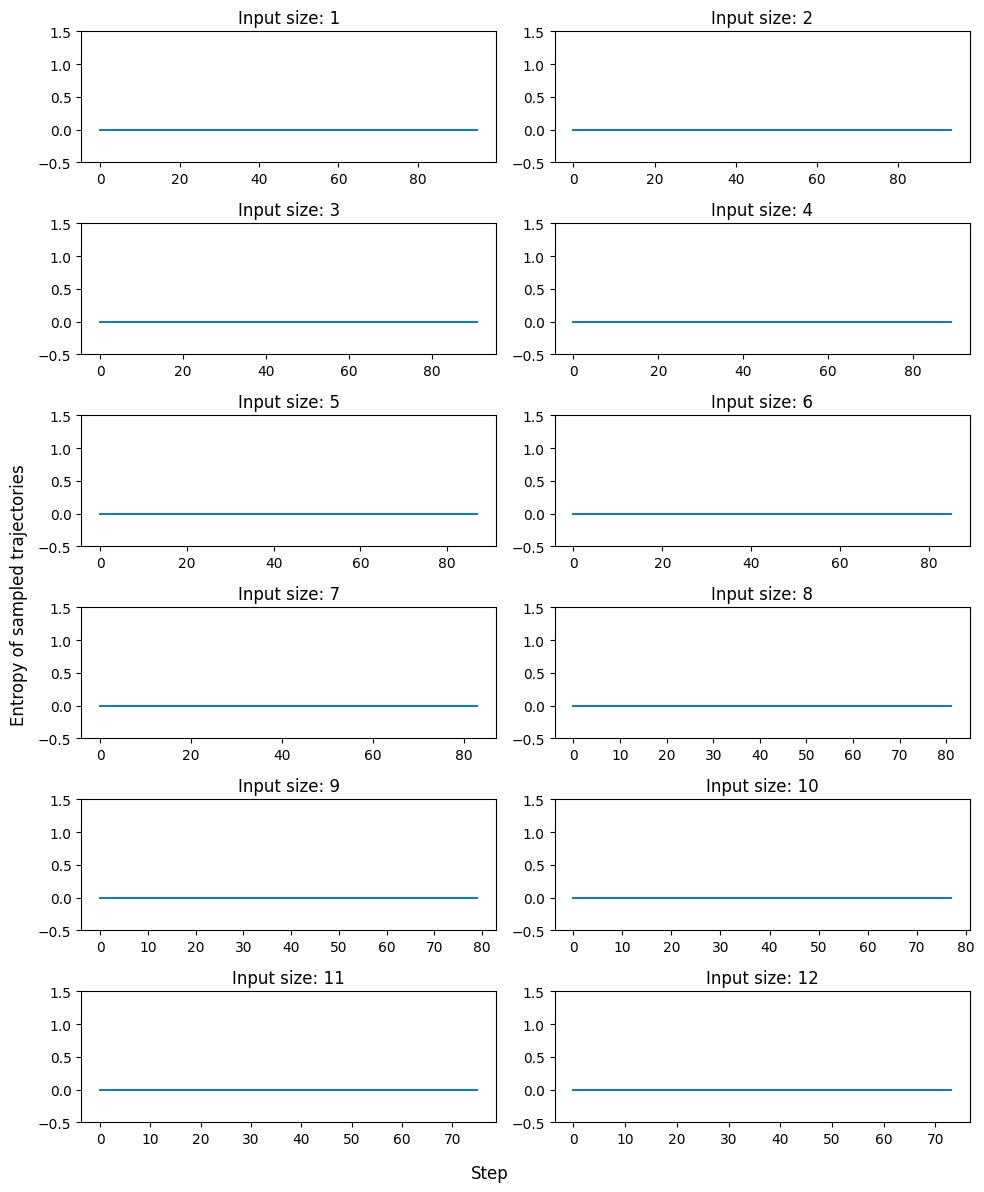

In [20]:
fig, axs = plt.subplots(
    int(np.ceil(len(all_res["results"][checkpoint_i].keys()) / 2)),
    2,
    figsize=(
        10,
        len(all_res["results"][checkpoint_i].keys())
    ),
)
axs = axs.flatten()

for plot_i, max_bits in enumerate(sorted(list(all_res["results"][checkpoint_i].keys()))):
    curr_actions = all_res["results"][checkpoint_i][max_bits]["actions"]
    curr_actions = curr_actions.reshape((-1, num_evals, curr_actions.shape[-1]))

    train_max_decode_len = 100
    x_range = np.arange(0, curr_actions.shape[0])
    question_end_idx = 2 * max_bits + 2

    accum_action_ent = np.zeros((
        len(x_range),
        train_max_decode_len - question_end_idx,
    ))

    for question_idx in range(curr_actions.shape[0]):
        action_counts = np.zeros((
            train_max_decode_len - question_end_idx,
            dataset.output_space.n
        ))

        for timestep_i in range(train_max_decode_len - question_end_idx):
            acts, counts = np.unique(
                curr_actions[question_idx, :, timestep_i + question_end_idx],
                return_counts=True,
            )

            for act, count in zip(acts, counts):
                action_counts[timestep_i, act] += count

        action_ent = scipy.stats.entropy(action_counts, axis=-1)
        accum_action_ent[question_idx] = action_ent

    axs[plot_i].plot(
        np.arange(train_max_decode_len - question_end_idx),
        np.mean(accum_action_ent, axis=0),
    )

    axs[plot_i].fill_between(
        np.arange(train_max_decode_len - question_end_idx),
        np.mean(accum_action_ent, axis=0) + np.std(accum_action_ent, axis=0) / num_evals,
        np.mean(accum_action_ent, axis=0) - np.std(accum_action_ent, axis=0) / num_evals,
        alpha=0.3
    )

    axs[plot_i].set_title(f"Input size: {max_bits}")
    axs[plot_i].set_ylim(-0.5, 1.5)

fig.supylabel('Entropy of sampled trajectories')
fig.supxlabel('Step')
fig.tight_layout()

In [21]:
for plot_i, max_bits in enumerate(sorted(list(all_res["results"][checkpoint_i].keys()))):
    curr_actions = all_res["results"][checkpoint_i][max_bits]["actions"]
    curr_obss = all_res["results"][checkpoint_i][max_bits]["observations"]
    curr_rlengthss = all_res["metrics"][checkpoint_i][max_bits]["response_lengths"]
    question_end_idx = 2 * max_bits + 1
    print("max bit: {}".format(max_bits))
    print("Q: {}".format(curr_obss[0][:question_end_idx]))

    print("O: {}".format(curr_obss[0][question_end_idx:question_end_idx + curr_rlengthss[0, 0].astype(int) + 1]))
    print("A: {}".format(curr_actions[0][question_end_idx + 1:question_end_idx + curr_rlengthss[0, 0].astype(int) + 1]))
    if len(curr_actions) > num_evals:
        print("Q: {}".format(curr_obss[num_evals][:question_end_idx]))
        print("O: {}".format(curr_obss[num_evals][question_end_idx:question_end_idx + curr_rlengthss[1, 0].astype(int) + 1]))
        print("A: {}".format(curr_actions[num_evals][question_end_idx + 1:question_end_idx + curr_rlengthss[1, 0].astype(int) + 1]))

max bit: 1
Q: [1 2 0]
O: [3 1]
A: [1]
max bit: 2
Q: [0 0 2 1 1]
O: [3 1 1]
A: [1 1]
Q: [1 0 2 0 1]
O: [3 1 1]
A: [1 1]
max bit: 3
Q: [0 1 0 2 0 0 1]
O: [3 0 1 1]
A: [0 1 1]
Q: [0 0 0 2 1 1 1]
O: [3 1 1 1]
A: [1 1 1]
max bit: 4
Q: [1 0 0 1 2 1 0 1 1]
O: [3 0 1 1 1 0 1 3 0 1 1 0 1]
A: [0 1 1 1 0 1 3 0 1 1 0 1]
Q: [1 1 1 1 2 1 0 0 0]
O: [3 0 1 1 1 1 0 1 3 0 1 0 0 1 3 0 1 0 0 0 1 3 0 0 0 1 0 1 3 0 0 1 0 1 3 0 0
 1 0 0 1 3 0 1 0 0 1 3 0 1 0 0 1 0 1 3 0 0 0 0 1]
A: [0 1 1 1 1 0 1 3 0 1 0 0 1 3 0 1 0 0 0 1 3 0 0 0 1 0 1 3 0 0 1 0 1 3 0 0 1
 0 0 1 3 0 1 0 0 1 3 0 1 0 0 1 0 1 3 0 0 0 0 1]
max bit: 5
Q: [1 0 0 0 1 2 1 1 0 1 0]
O: [3 0 1 1 1 1 1 3 0 1 0 1 1 3 0 1 0 1 1 1 3 0 0 1 1 1]
A: [0 1 1 1 1 1 3 0 1 0 1 1 3 0 1 0 1 1 1 3 0 0 1 1 1]
Q: [0 1 1 0 1 2 1 0 0 1 1]
O: [3 1 1 1 1 0 1]
A: [1 1 1 1 0 1]
max bit: 6
Q: [0 1 1 1 1 1 2 0 1 0 0 1 0]
O: [3 0 1 1 1 1 1 0 1 3 0 1 0 0 1 0 1 3 0 0 0 1 0 0 1 3 0 0 1 0 1 0 1 3 0 0 1
 0 1 0 1 3 0 0 1 0 1 0 1 3 0 0 0 0 1 0 1]
A: [0 1 1 1 1 1 0 1 3 0 1 0 0 1 0 1 3 

In [22]:
for plot_i, max_bits in enumerate(sorted(list(all_res["results"][checkpoint_i].keys()))):
    curr_actions = all_res["results"][checkpoint_i][max_bits]["actions"]
    curr_obss = all_res["results"][checkpoint_i][max_bits]["observations"]
    question_end_idx = 2 * max_bits + 1
    print(jnp.vstack((curr_obss[0][:30], curr_actions[0][1:31])))

[[1 2 0 3 1 1 0 1 3 1 0 1 0 1 3 1 1 1 0 1 3 1 1 1 0 1 3 1 1 0]
 [1 1 1 1 1 0 1 3 1 0 1 0 1 3 1 1 1 0 1 3 1 1 1 0 1 3 1 1 0 1]]
[[0 0 2 1 1 3 1 1 1 1 3 1 1 0 1 3 1 0 1 0 1 3 1 0 1 1 3 1 0 1]
 [1 1 1 1 1 1 1 1 1 3 1 1 0 1 3 1 0 1 0 1 3 1 0 1 1 3 1 0 1 0]]
[[0 1 0 2 0 0 1 3 0 1 1 1 1 3 0 1 1 0 1 3 0 1 1 0 1 3 0 1 0 1]
 [1 1 1 1 1 1 1 0 1 1 1 1 3 0 1 1 0 1 3 0 1 1 0 1 3 0 1 0 1 3]]
[[1 0 0 1 2 1 0 1 1 3 0 1 1 1 0 1 3 0 1 1 0 1 3 0 1 1 1 0 1 3]
 [1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 3 0 1 1 0 1 3 0 1 1 1 0 1 3 0]]
[[1 0 0 0 1 2 1 1 0 1 0 3 0 1 1 1 1 1 3 0 1 0 1 1 3 0 1 0 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 3 0 1 0 1 1 3 0 1 0 1 1 1]]
[[0 1 1 1 1 1 2 0 1 0 0 1 0 3 0 1 1 1 1 1 0 1 3 0 1 0 0 1 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 3 0 1 0 0 1 0 1 3]]
[[0 1 0 0 1 0 1 2 0 0 1 1 1 0 0 3 0 1 1 1 1 1 1 3 0 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 3 0 1 1 1 1 1 3]]
[[1 1 1 1 0 1 1 0 2 0 1 0 1 0 0 0 1 3 1 1 1 1 1 1 1 3 1 1 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

In [23]:
all_res["results"][checkpoint_i][3]["observations"][0, :-1]

Array([0, 1, 0, ..., 1, 3, 0], dtype=int32)

In [24]:
all_res["results"][checkpoint_i][3]["actions"][0, 1:]

Array([1, 1, 1, ..., 3, 0, 1], dtype=int32)

In [25]:
pred_mask = np.zeros(all_res["results"][checkpoint_i][3]["observations"].shape[-1])
pred_mask[all_res["results"][checkpoint_i][3]["last_prompt_idx"][0]:] = 1
pred_mask

array([0., 0., 0., ..., 1., 1., 1.], shape=(3201,))

In [26]:
all_res["metrics"][checkpoint_i][3]["successes"][0], all_res["metrics"][checkpoint_i][3]["response_lengths"][0]

(array([1.]), array([3.]))

## Pass@K

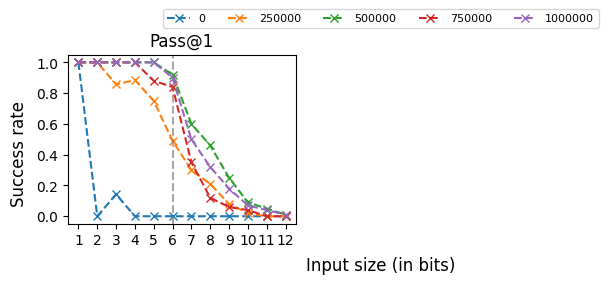

In [27]:
skip_step = 5
checkpoints = None
max_pow = int(np.log2(num_evals)) + 1

num_cols = 3
num_rows = int(np.ceil(max_pow / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(2.5 * num_cols, 2.5 * num_rows))

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

axes = axes.flatten()
for plot_i in range(max_pow):
    ax = axes[plot_i]
    curr_k = int(2 ** plot_i)
    for checkpoint_i, curr_metric in all_res["metrics"].items():
        if checkpoints:
            if checkpoint_i not in checkpoints:
                continue
        else:
            if (
                checkpoint_i != last_checkpoint
                and checkpoint_i > 0
                and checkpoint_i % skip_step != 0
            ):
                continue

        input_length_range = sorted(curr_metric.keys())
        expected_successes = []
        for num_bits in input_length_range:
            successes = np.max(curr_metric[num_bits]["successes"][:, :curr_k], axis=-1)
            expected_successes.append((
                np.mean(successes),
                np.std(successes) / np.sqrt(len(successes)),
            ))

        expected_successes = np.array(expected_successes)

        ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)
        ax.plot(
            input_length_range,
            expected_successes[:, 0],
            marker="x",
            linestyle="--",
            label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 0 else "",
        )
    ax.set_xticks(input_length_range)
    ax.set_title(f"Pass@{curr_k}")

    if plot_i % num_cols != 0:
        ax.set_yticks([])

for i in range(max_pow, len(axes)):
    fig.delaxes(axes[i])

fig.supylabel("Success rate")
fig.supxlabel("Input size (in bits)")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

[0, 5, 10, 15, 20]


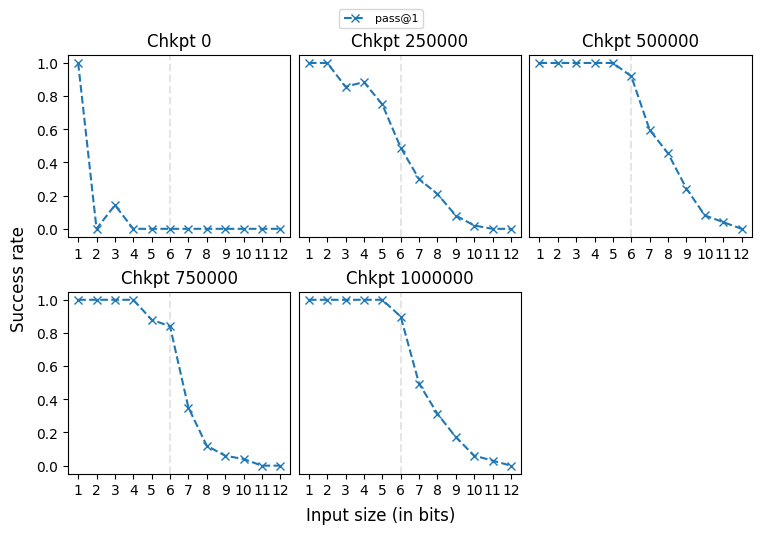

In [28]:
skip_step = 5
checkpoints = None
max_pow = int(np.log2(num_evals)) + 1
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

if checkpoints is None:
    checkpoints = []
    for checkpoint_i in all_res["metrics"].keys():
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue
        checkpoints.append(checkpoint_i)

print(checkpoints)

num_cols = 3
num_rows = int(np.ceil(len(checkpoints) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(2.5 * num_cols, 2.5 * num_rows))

axes = axes.flatten()
for plot_i, checkpoint_i in enumerate(checkpoints):
    ax = axes[plot_i]

    curr_metric = all_res["metrics"][checkpoint_i]
    for curr_pow in range(max_pow):
        curr_k = int(2 ** curr_pow)
        
        input_length_range = sorted(curr_metric.keys())
        expected_successes = []
        for num_bits in input_length_range:
            successes = np.max(curr_metric[num_bits]["successes"][:, :curr_k], axis=-1)
            expected_successes.append((
                np.mean(successes),
                np.std(successes) / np.sqrt(len(successes)),
            ))

        expected_successes = np.array(expected_successes)

        ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)

        ax.plot(
            input_length_range,
            expected_successes[:, 0],
            marker="x",
            linestyle="--",
            label=f"pass@{curr_k}" if plot_i == 0 else "",
        )
    ax.set_xticks(input_length_range)
    ax.set_title(f"Chkpt {checkpoint_i * checkpoint_interval}")

    if plot_i % num_cols != 0:
        ax.set_yticks([])

for i in range(len(checkpoints), len(axes)):
    fig.delaxes(axes[i])

fig.supylabel("Success rate")
fig.supxlabel("Input size (in bits)")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

## Generalization Gaps

[0, 5, 10, 15, 20]
[6, 7, 8, 9, 10, 11, 12]


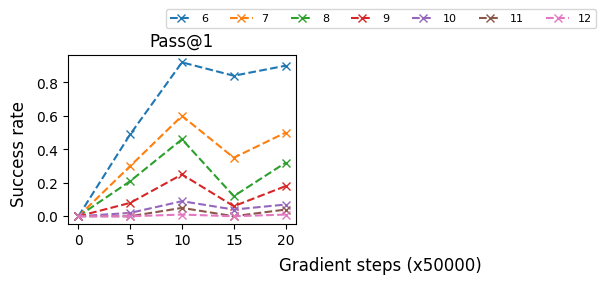

In [29]:
skip_step = 5
checkpoints = None
max_pow = int(np.log2(num_evals)) + 1
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

if checkpoints is None:
    checkpoints = []
    for checkpoint_i in all_res["metrics"].keys():
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue
        checkpoints.append(checkpoint_i)

print(checkpoints)
x_range = [checkpoint for checkpoint in checkpoints]

input_length_range = sorted(all_res["metrics"][checkpoints[0]].keys())
input_length_range = input_length_range[int(np.ceil(np.log2(train_max_int))) - 1:]
print(input_length_range)

num_cols = 3
num_rows = int(np.ceil(max_pow / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(2.5 * num_cols, 2.5 * num_rows))

axes = axes.flatten()
for plot_i in range(max_pow):
    ax = axes[plot_i]
    curr_k = int(2 ** plot_i)
    for num_bits in input_length_range:
        expected_successes = []
        for checkpoint_i in checkpoints:
            curr_metric = all_res["metrics"][checkpoint_i]
            successes = np.max(curr_metric[num_bits]["successes"][:, :curr_k], axis=-1)
            expected_successes.append((
                np.mean(successes),
                np.std(successes) / np.sqrt(len(successes)),
            ))

        expected_successes = np.array(expected_successes)

        ax.plot(
            x_range,
            expected_successes[:, 0],
            marker="x",
            linestyle="--",
            label=f"{num_bits}" if plot_i == 0 else "",
        )
    ax.set_xticks(x_range)
    ax.set_title(f"Pass@{curr_k}")

    if plot_i % num_cols != 0:
        ax.set_yticks([])

for i in range(num_evals, len(axes)):
    fig.delaxes(axes[i])

fig.supylabel("Success rate")
fig.supxlabel(f"Gradient steps (x{checkpoint_interval})")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

## Serial vs Parallel

In [53]:
parallel_results_path = "res-ppo-scratch_1M-no_cot_tokens-8x8-10-22-25_07_46_47-89a2c565-e62c-48da-a13c-b345bb018474-decode_len_100-num_evals_64.dill"
serial_results_path = "res-ppo-scratch_1M-no_cot_tokens-8x8-10-22-25_07_46_47-89a2c565-e62c-48da-a13c-b345bb018474-decode_len_3200-num_evals_1.dill"

# parallel_results_path = "res-ppo-scratch_1M-no_correctness_aware-no_cot_tokens-8x8-10-22-25_07_49_04-456e8ca1-b8b5-434a-bbb1-40412b326c36-decode_len_100-num_evals_32.dill"
# serial_results_path = "res-ppo-scratch_1M-no_correctness_aware-no_cot_tokens-8x8-10-22-25_07_49_04-456e8ca1-b8b5-434a-bbb1-40412b326c36-decode_len_3200-num_evals_1.dill"

parallel_res = dill.load(open(parallel_results_path, "rb"))
serial_res = dill.load(open(serial_results_path, "rb"))

[0, 5, 10, 15, 20]


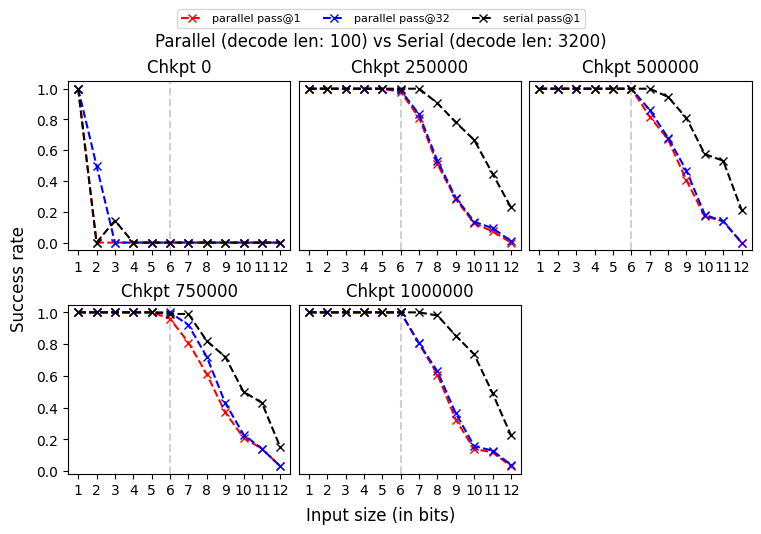

In [54]:
skip_step = 5
checkpoints = None
max_pow = int(np.log2(num_evals)) + 1
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

if checkpoints is None:
    checkpoints = []
    for checkpoint_i in all_res["metrics"].keys():
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue
        checkpoints.append(checkpoint_i)

print(checkpoints)

num_cols = 3
num_rows = int(np.ceil(len(checkpoints) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(2.5 * num_cols, 2.5 * num_rows))

axes = axes.flatten()
for plot_i, checkpoint_i in enumerate(checkpoints):
    ax = axes[plot_i]

    curr_metric = parallel_res["metrics"][checkpoint_i]
    input_length_range = sorted(curr_metric.keys())
    
    # max_k = curr_metric[num_bits]["successes"].shape[1]
    max_k = 32

    # Pass@1
    expected_successes = []
    for num_bits in input_length_range:
        successes = np.max(curr_metric[num_bits]["successes"][:, :1], axis=-1)
        expected_successes.append((
            np.mean(successes),
            np.std(successes) / np.sqrt(len(successes)),
        ))

    expected_successes = np.array(expected_successes)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)

    ax.plot(
        input_length_range,
        expected_successes[:, 0],
        marker="x",
        linestyle="--",
        label=f"parallel pass@1" if plot_i == 0 else "",
        c="red",
    )

    # Pass@MAX
    expected_successes = []
    for num_bits in input_length_range:
        successes = np.max(curr_metric[num_bits]["successes"], axis=-1)
        expected_successes.append((
            np.mean(successes),
            np.std(successes) / np.sqrt(len(successes)),
        ))

    expected_successes = np.array(expected_successes)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)

    ax.plot(
        input_length_range,
        expected_successes[:, 0],
        marker="x",
        linestyle="--",
        label=f"parallel pass@{max_k}" if plot_i == 0 else "",
        c="blue",
    )

    # Pass@1 Serial
    curr_metric = serial_res["metrics"][checkpoint_i]
    input_length_range = sorted(curr_metric.keys())
    expected_successes = []
    for num_bits in input_length_range:
        successes = np.max(curr_metric[num_bits]["successes"][:, :1], axis=-1)
        expected_successes.append((
            np.mean(successes),
            np.std(successes) / np.sqrt(len(successes)),
        ))

    expected_successes = np.array(expected_successes)

    ax.plot(
        input_length_range,
        expected_successes[:, 0],
        marker="x",
        linestyle="--",
        label=f"serial pass@1" if plot_i == 0 else "",
        c="black",
    )


    ax.set_xticks(input_length_range)
    ax.set_title(f"Chkpt {checkpoint_i * checkpoint_interval}")

    if plot_i % num_cols != 0:
        ax.set_yticks([])

for i in range(len(checkpoints), len(axes)):
    fig.delaxes(axes[i])

serial_decode_len = serial_res["results"][checkpoint_i][max(input_length_range)]["actions"].shape[-1] - 1
parallel_decode_len = parallel_res["results"][checkpoint_i][max(input_length_range)]["actions"].shape[-1] - 1
fig.suptitle(f"Parallel (decode len: {parallel_decode_len}) vs Serial (decode len: {serial_decode_len})")
fig.supylabel("Success rate")
fig.supxlabel("Input size (in bits)")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

[0, 5, 10, 15, 20]


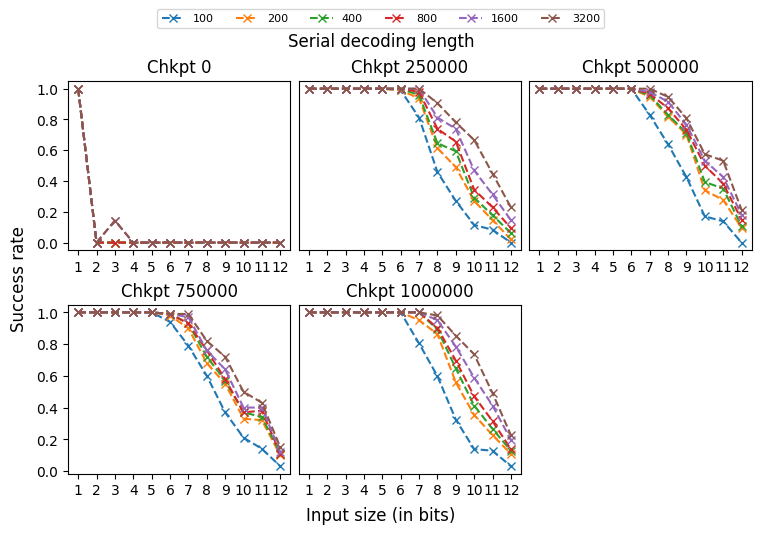

In [106]:
skip_step = 5
checkpoints = None
max_decode_len = 3200
decode_lens = np.arange(0, np.ceil(np.log2(max_decode_len / 100)).astype(int) + 1)

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

if checkpoints is None:
    checkpoints = []
    for checkpoint_i in all_res["metrics"].keys():
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue
        checkpoints.append(checkpoint_i)

print(checkpoints)

num_cols = 3
num_rows = int(np.ceil(len(checkpoints) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(2.5 * num_cols, 2.5 * num_rows))

axes = axes.flatten()
for plot_i, checkpoint_i in enumerate(checkpoints):
    ax = axes[plot_i]

    curr_metric = serial_res["metrics"][checkpoint_i]
    input_length_range = sorted(curr_metric.keys())
    
    # max_k = curr_metric[num_bits]["successes"].shape[1]
    max_k = 32

    # Pass@1 Serial
    curr_metric = serial_res["metrics"][checkpoint_i]
    input_length_range = sorted(curr_metric.keys())
    for decode_len in decode_lens:
        expected_successes = []
        pow = 2 ** decode_len * 100
        for num_bits in input_length_range:
            response_lengths = curr_metric[num_bits]["response_lengths"]
            valid_indices = response_lengths[:, :1] <= pow - (2 * num_bits + 2)
            successes = np.max(
                curr_metric[num_bits]["successes"][:, :1] * valid_indices,
                axis=-1,
            )
            expected_successes.append((
                np.mean(successes),
                np.std(successes) / np.sqrt(len(successes)),
            ))

        expected_successes = np.array(expected_successes)

        ax.plot(
            input_length_range,
            expected_successes[:, 0],
            marker="x",
            linestyle="--",
            label=f"{pow}" if plot_i == 0 else "",
        )

    ax.set_xticks(input_length_range)
    ax.set_title(f"Chkpt {checkpoint_i * checkpoint_interval}")

    if plot_i % num_cols != 0:
        ax.set_yticks([])

for i in range(len(checkpoints), len(axes)):
    fig.delaxes(axes[i])

serial_decode_len = serial_res["results"][checkpoint_i][max(input_length_range)]["actions"].shape[-1] - 1
parallel_decode_len = parallel_res["results"][checkpoint_i][max(input_length_range)]["actions"].shape[-1] - 1
fig.suptitle(f"Serial decoding length")
fig.supylabel("Success rate")
fig.supxlabel("Input size (in bits)")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

## $\pi(a|s)$ vs $\pi(a|s, c)$

In [30]:
sorted(list(all_res["results"][checkpoint_i].keys())) # bits

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [31]:
sorted(list(all_res["results"].keys())) # checkpoints

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [32]:
checkpoint_i = 15
max_bits = 3

In [33]:
curr_actions = all_res["results"][checkpoint_i][max_bits]["actions"]
curr_obss = all_res["results"][checkpoint_i][max_bits]["observations"]
curr_rlengthss = all_res["metrics"][checkpoint_i][max_bits]["response_lengths"]
curr_logits = all_res["results"][checkpoint_i][max_bits]["logits"]

In [34]:
curr_obss[0]

Array([0, 1, 0, ..., 3, 0, 1], dtype=int32)

In [35]:
curr_actions[0]

Array([0, 1, 1, ..., 3, 0, 1], dtype=int32)

In [36]:
last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
train_state = dill.load(
    open(os.path.join(learner_path, "models", last_step), "rb")
)

# print(train_state.params)
model = nnx.merge(
    train_state.graphdef,
    train_state.params,
    train_state.rest,
)
model.set_attributes(deterministic=False, decode=False)

In [37]:
question = curr_obss[0][:np.where(curr_obss[0] == 3)[0][0] + 1].tolist()
question

[0, 1, 0, 2, 0, 0, 1, 3]

In [38]:
max_decode_len = 15

logits = model({
    "sequence": np.array([
        question + [4] * (max_decode_len - len(question)),
        question + [6] + [4] * (max_decode_len - len(question) - 1),
        question + [6, 3] + [4] * (max_decode_len - len(question) - 2),
        question + [0, 5] + [4] * (max_decode_len - len(question) - 2),
        question + [0, 5, 3] + [4] * (max_decode_len - len(question) - 3),
        question + [0, 5, 3, 0] + [4] * (max_decode_len - len(question) - 4),
        question + [0] + [4] * (max_decode_len - len(question) - 1),
    ])
})

In [39]:
logits[0, len(question) - 1]

Array([ 22.116192 , -19.53534  ,  -6.689564 ,  -4.5265083], dtype=float32)

In [40]:
logits[1, len(question) + 0]

Array([nan, nan, nan, nan], dtype=float32)

In [41]:
logits[2, len(question) + 1]

Array([nan, nan, nan, nan], dtype=float32)

In [42]:
logits[3, len(question) + 1]

Array([nan, nan, nan, nan], dtype=float32)

In [43]:
logits[4, len(question) + 2]

Array([nan, nan, nan, nan], dtype=float32)

In [44]:
logits[5, len(question) + 3]

Array([nan, nan, nan, nan], dtype=float32)

In [45]:
logits[6, len(question) + 0]

Array([-19.495613  ,  23.068071  ,  -0.04207629,  -0.687992  ], dtype=float32)

In [46]:
nnx.log_softmax(logits[6, len(question) + 0])

Array([-42.563683,   0.      , -23.110147, -23.756063], dtype=float32)

In [47]:
nnx.log_softmax(logits[5, len(question) + 3])

Array([nan, nan, nan, nan], dtype=float32)